In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data <- readRDS('GCA_obj_subset_excludecells3.Rdata')

In [4]:
data@meta.data$celltype  %>% unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [5]:
data@meta.data  %>% filter(Maincelltype == 'Epithelium'|Maincelltype == 'Lymphocyte'|Maincelltype == 'Phagocyte')  %>%
            filter(!celltype == 'Epi_normal')  %>% 
            rownames()  %>% data[,.] -> data_epi

In [6]:
data@meta.data  %>% filter(celltype == 'Epi_tumor')  %>% rownames()  -> epi_tumor_barcodes

In [7]:
data_epi$celltype  %>% unique()

[1] "CD4+ T"         "Plasma"         "Regulatory T"   "NKcell"        
 [5] "Neutrophils"    "Bcell"          "CD8+ Low"       "MacrophageM2"  
 [9] "Epi_tumor"      "Monocytes"      "CD8+ T"         "MacrophageM1"  
[13] "Mastcell"       "DendriticCells"

In [8]:
data_epi@meta.data  %>% filter(!celltype == 'Epi_tumor')  %>% rownames() -> normallabels

In [9]:
length(normallabels)

[1] 30745

### run copycat

In [15]:
#library(copykat)

In [16]:
#copykat.test <- copykat(rawmat=data_epi_counts, id.type="S", ngene.chr=5, win.size=25, KS.cut=0.1, 
#                        sam.name="copykat2", distance="euclidean", norm.cell.names=normallabels,output.seg="FLASE",
#                        plot.genes="TRUE", genome="hg20",n.cores=20)

In [17]:
copykat2 <- read.table('copykat2_copykat_prediction.txt',header=T)

In [18]:
rownames(copykat2) <- copykat2$cell.names

In [19]:
data@meta.data  %>% filter(celltype=='Epi_tumor')  %>% filter(sample %in% c('SC008','SC005','SC027'))  %>% 
    rownames()  -> low_cellbarcodes
data@meta.data  %>% filter(celltype=='Epi_tumor')  %>% filter(sample %in% c('SC032','SC017','SC015','SC031'))  %>% 
    rownames()  -> high_cellbarcodes

In [20]:
copykat2  %>% filter(!copykat.pred=='not.defined') -> copykat3

In [21]:
low_cellbarcodes  %>% length()

[1] 1756

In [22]:
high_cellbarcodes  %>% length()

[1] 3375

In [23]:
low_cellbarcodes  %>% intersect(rownames(copykat3))  -> low_cellbarcodes

In [24]:
high_cellbarcodes  %>% intersect(rownames(copykat3))  -> high_cellbarcodes

In [25]:
copykat3[low_cellbarcodes,]  %>% count(copykat.pred)  %>% 
    reframe(pct = n/sum(n),copykat.pred = copykat.pred,group = 'low',n = n) -> low

In [26]:
copykat3[high_cellbarcodes,] %>% count(copykat.pred) %>% 
    reframe(pct = n/sum(n),copykat.pred = copykat.pred,group = 'high',n = n) -> high

In [27]:
rbind(low,high) -> low_high

In [28]:
low_high$pct <- low_high$pct*100

In [29]:
low_high  %>% mutate(pct2 = paste0(round(pct,2),'%')) -> low_high

In [30]:
chisq.test(matrix(c(982,479,2619,604),ncol=2))


	Pearson's Chi-squared test with Yates' continuity correction

data:  matrix(c(982, 479, 2619, 604), ncol = 2)
X-squared = 110.78, df = 1, p-value < 2.2e-16


In [31]:
#library(rcompanion)

ERROR: Error in library(rcompanion): there is no package called ‘rcompanion’


In [32]:
cramerV(matrix(c(982,479,2619,604),ncol=2))

ERROR: Error in cramerV(matrix(c(982, 479, 2619, 604), ncol = 2)): could not find function "cramerV"


In [36]:
matrix(c(982,479,2619,604),ncol=2)

982,2619
479,604


In [37]:
options(repr.plot.height=5,repr.plot.width=4)
p6 <- ggplot(data = low_high,aes(x=group,y=pct,fill = copykat.pred)) +geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=10),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1,size=15))+
    geom_text(aes(label = pct2),position = position_stack(vjust = 0.5))

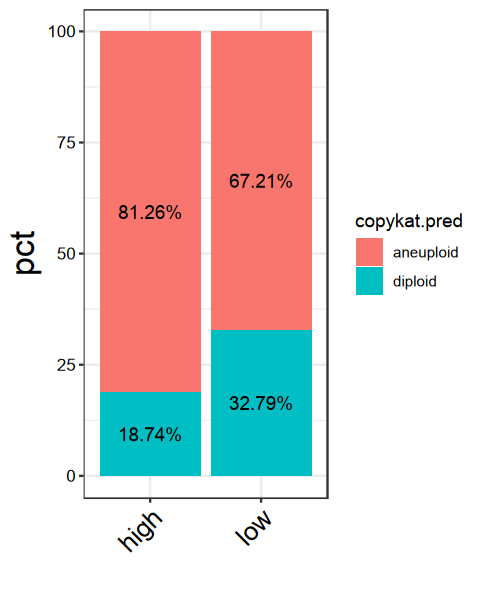

In [38]:
p6

In [ ]:
ggsave(filename = "Ploidy_epitumor_high_low.pdf",plot = p6,width = 4,height = 5)

### sample by sample

In [39]:
lownames <- c('SC008','SC005','SC027')
highnames <- c('SC032','SC017','SC015','SC031')

In [40]:
copykat3[c(low_cellbarcodes,high_cellbarcodes),] -> copykat3_2

In [41]:
copykat3_2$cell.names  %>% str_split('-')  %>% map_chr(last) -> copykat3_2$sample

In [42]:
copykat3_2  %>% count(copykat.pred,sample) -> copykat_sample

In [43]:
copykat_sample  %>% pivot_wider(names_from = c(copykat.pred),values_from = n) -> copykat_sample_wider

In [44]:
copykat_sample_wider

sample,aneuploid,diploid
<chr>,<int>,<int>
SC005,353,231
SC008,311,197
SC015,321,272
SC017,1170,156
SC027,318,51
SC031,806,66
SC032,322,110


In [45]:
copykat_sample_wider  %>% reframe(Aneuploid = aneuploid/(aneuploid+diploid),Diploid = diploid/(aneuploid+diploid),sample = sample)  %>% as.data.frame() ->copykat_sample_wider2 
rownames(copykat_sample_wider2) <- copykat_sample_wider2$sample

In [46]:
copykat_sample_wider2

,Aneuploid,Diploid,sample
,<dbl>,<dbl>,<chr>
SC005,0.6044521,0.39554795,SC005
SC008,0.6122047,0.38779528,SC008
SC015,0.5413153,0.45868465,SC015
SC017,0.8823529,0.11764706,SC017
SC027,0.8617886,0.13821138,SC027
SC031,0.9243119,0.07568807,SC031
SC032,0.7453704,0.25462963,SC032


In [47]:
copykat_sample_wider2  %>% mutate(group = ifelse(sample %in% lownames,'low','high')) -> copykat_sample_wider3
copykat_sample_wider3  %>% pivot_longer(!c(group,sample),values_to = 'Percentage',names_to = 'cnv') -> copykat_sample_wider4
copykat_sample_wider4  %>% mutate(pct2 = paste0(round(Percentage*100),'%')) -> copykat_sample_wider4

In [48]:
copykat_sample_wider4$sample <- factor(copykat_sample_wider4$sample, levels = 
                             c('SC008','SC005','SC027','SC032','SC017','SC015','SC031'))


In [49]:
copykat_sample_wider4

sample,group,cnv,Percentage,pct2
<fct>,<chr>,<chr>,<dbl>,<chr>
SC005,low,Aneuploid,0.60445205,60%
SC005,low,Diploid,0.39554795,40%
SC008,low,Aneuploid,0.61220472,61%
SC008,low,Diploid,0.38779528,39%
SC015,high,Aneuploid,0.54131535,54%
SC015,high,Diploid,0.45868465,46%
SC017,high,Aneuploid,0.88235294,88%
SC017,high,Diploid,0.11764706,12%
SC027,low,Aneuploid,0.86178862,86%


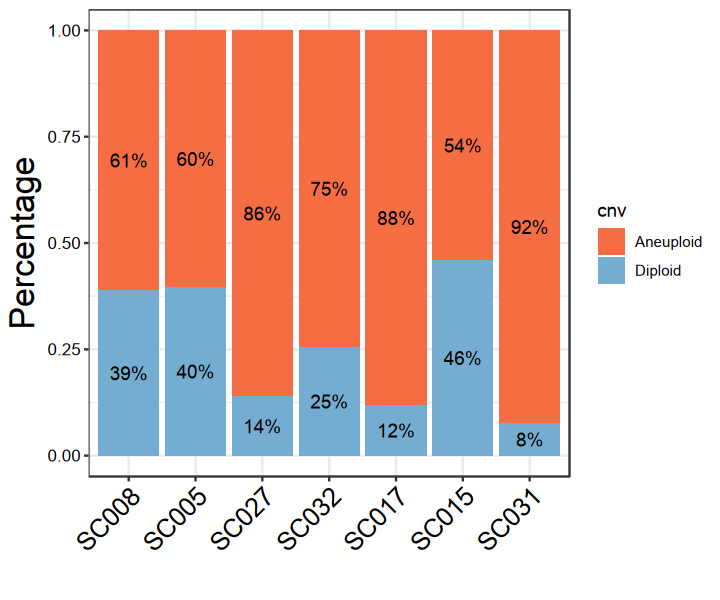

In [50]:
options(repr.plot.height=5,repr.plot.width=6)
p1 <- ggplot(data = copykat_sample_wider4,aes(x=sample,y=Percentage,fill = cnv)) +geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=10),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1,size=15))+
    geom_text(aes(label = pct2),position = position_stack(vjust = 0.5))+
    scale_fill_manual(values = c('#f46d43','#74add1'))
p1

In [51]:
ggsave(filename = "ploidy_each_sample.pdf",plot = p1,width = 6,height = 5)

In [52]:
copykat_sample_wider3  %>% group_by(group)  %>% reframe(Mean = mean(Aneuploid),sd = sd(Aneuploid),
                                                        group = group)  %>% unique() -> copykat_sample_wider3_forbar

In [53]:
copykat_sample_wider3

,Aneuploid,Diploid,sample,group
,<dbl>,<dbl>,<chr>,<chr>
SC005,0.6044521,0.39554795,SC005,low
SC008,0.6122047,0.38779528,SC008,low
SC015,0.5413153,0.45868465,SC015,high
SC017,0.8823529,0.11764706,SC017,high
SC027,0.8617886,0.13821138,SC027,low
SC031,0.9243119,0.07568807,SC031,high
SC032,0.7453704,0.25462963,SC032,high


In [54]:
p2 <- ggplot(copykat_sample_wider3_forbar) +
    geom_bar( aes(x=group, y=Mean), stat="identity", fill="#f46d43", alpha=1) +
    geom_errorbar( aes(x=group, ymin=Mean-sd, ymax=Mean+sd), width=0.4, alpha=1, size=0.8)+theme_bw()+
    xlab("")+theme(axis.text = element_text(color='black',size=10),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(hjust=1,size=15))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


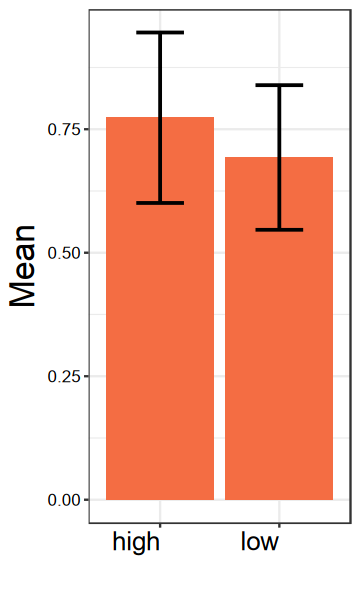

In [55]:
options(repr.plot.height=5,repr.plot.width=3)
p2

In [58]:
copykat_sample_wider3[,c('Aneuploid','sample','group')]

,Aneuploid,Diploid,sample,group
,<dbl>,<dbl>,<chr>,<chr>
SC005,0.6044521,0.39554795,SC005,low
SC008,0.6122047,0.38779528,SC008,low
SC015,0.5413153,0.45868465,SC015,high
SC017,0.8823529,0.11764706,SC017,high
SC027,0.8617886,0.13821138,SC027,low
SC031,0.9243119,0.07568807,SC031,high
SC032,0.7453704,0.25462963,SC032,high


In [59]:
saveRDS(copykat_sample_wider3[,c('Aneuploid','sample','group')],
        file = "/disk1/pengweixing/esophageal/21.singlecell/08.infercnv/individual_sample/b4.Rds")

In [83]:
ggsave(filename = "ploidy_compare_barplot.pdf",plot = p2,width = 3,height = 5)

In [60]:
t.test(c(0.6044521,0.6122047,0.8617886),c(0.5413153,0.8823529,0.9243119,0.7453704))


	Welch Two Sample t-test

data:  c(0.6044521, 0.6122047, 0.8617886) and c(0.5413153, 0.8823529, 0.9243119, 0.7453704)
t = -0.66677, df = 4.8375, p-value = 0.5354
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.394121  0.233076
sample estimates:
mean of x mean of y 
0.6928151 0.7733376 


In [61]:
save.image('copycat2.Rds')